In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.stats import shapiro
from scipy.stats import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols 

# Part 1: EDA 

In [2]:
df = pd.read_csv('for_ab_test.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2795 entries, 0 to 2794
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   grp               2795 non-null   object
 1   applies           2795 non-null   int64 
 2   read_applies      2795 non-null   int64 
 3   answered_applies  2795 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 87.5+ KB


In [4]:
df.head()

,grp,applies,read_applies,answered_applies
0,test,42,7,0
1,test,7,6,6
2,test,2,2,2
3,test,17,14,12
4,test,282,135,58


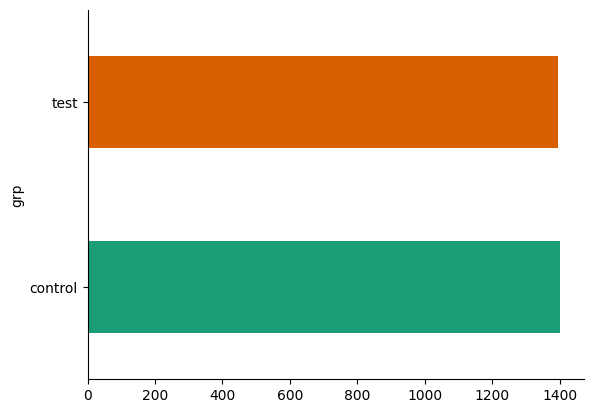

In [5]:
# title grp
df.groupby('grp').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top','right']].set_visible(False)

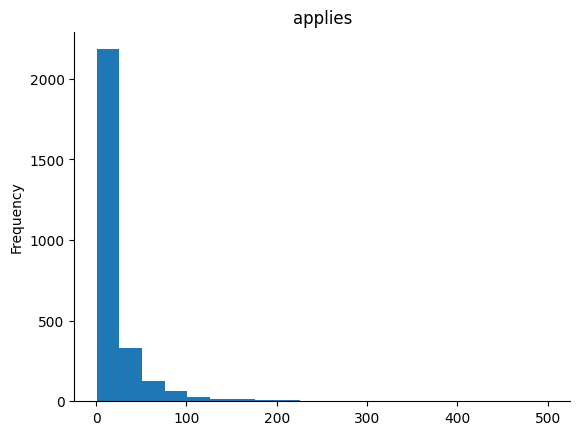

In [6]:
# title applies distribution.

df['applies'].plot(kind='hist', bins=20, title='applies')
plt.gca().spines[['top', 'right']].set_visible(False)

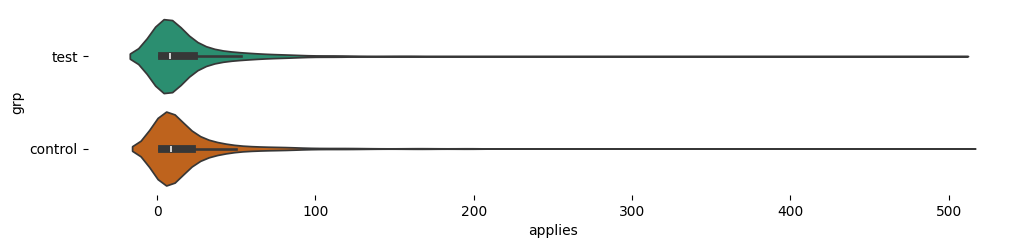

In [7]:
# title grv vs applies
figsize = (12, 1.2 * len(df['grp'].unique()))
plt.figure(figsize=figsize)

sns.violinplot(df, x='applies', y='grp', hue='grp', inner='box', palette='Dark2', legend=False)
sns.despine(top=True, bottom=True, right=True, left=True)



In [8]:
df.describe()

,applies,read_applies,answered_applies
count,2795.000000,2795.000000,2795.000000
mean,20.744544,10.129517,5.292308
std,37.333786,21.084884,14.510162
min,1.000000,0.000000,0.000000
25%,3.000000,1.000000,0.000000
50%,9.000000,4.000000,1.000000
75%,22.000000,11.000000,4.000000
max,500.000000,482.000000,216.000000


In [9]:
df.head()

,grp,applies,read_applies,answered_applies
0,test,42,7,0
1,test,7,6,6
2,test,2,2,2
3,test,17,14,12
4,test,282,135,58


In [10]:
df.groupby('grp').size()

grp
control    1400
test       1395
dtype: int64

# Part 2: Test

# Option One: AB test calculator

In [11]:
# option one: ab test calculator
df.groupby('grp').sum()

,applies,read_applies,answered_applies
grp,,,
control,28331,13363,6920
test,29650,14949,7872


https://abtestguide.com/calc/

or https://www.evanmiller.org/ab-testing/chi-squared.html

**Read Rate** Significant test result! Variation B's observed conversion rate (50.42%) was 6.89% higher than variation A's conversion rate (47.17%). You can be 95% confident that this result is a  consequence of the changes you made and not a result of random chance.

**Answer Rate** Significant test result! Variation B's observed conversion rate (26.55%) was 8.70% higher than variation A's conversion rate (24.43%). You can be 95% confident that this result is a consequence of the changes you made and not a result of random chance.

**Read to Answer Conversion** The test result is not significant. The observed difference in conversion rate (1.69%) isn't big enough to declare a significant winner. There is no real difference in performance between A and B or you need to collect more data.

# Option Two: Bootstrap

In [12]:
df['read_pct'] = df['read_applies'] / df['applies']
df['answered_pct'] = df['answered_applies'] / df['applies']
# to avoid dividing by zero and getting NaN
df['read2answered'] = np.where(df['read_applies'] == 0, 0, df['answered_applies'] / df['read_applies'])

In [13]:
df

,grp,applies,read_applies,answered_applies,read_pct,answered_pct,read2answered
0,test,42,7,0,0.166667,0.000000,0.000000
1,test,7,6,6,0.857143,0.857143,1.000000
2,test,2,2,2,1.000000,1.000000,1.000000
3,test,17,14,12,0.823529,0.705882,0.857143
4,test,282,135,58,0.478723,0.205674,0.429630
...,...,...,...,...,...,...,...
2790,control,8,8,3,1.000000,0.375000,0.375000
2791,test,16,16,8,1.000000,0.500000,0.500000
2792,test,5,1,0,0.200000,0.000000,0.000000
2793,control,18,16,0,0.888889,0.000000,0.000000


In [14]:
df.describe()

,applies,read_applies,answered_applies,read_pct,answered_pct,read2answered
count,2795.000000,2795.000000,2795.000000,2795.000000,2795.000000,2795.000000
mean,20.744544,10.129517,5.292308,0.559519,0.285025,0.377164
std,37.333786,21.084884,14.510162,0.395518,0.358466,0.412878
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,0.000000,0.142857,0.000000,0.000000
50%,9.000000,4.000000,1.000000,0.625000,0.078947,0.176471
75%,22.000000,11.000000,4.000000,1.000000,0.500000,0.833333
max,500.000000,482.000000,216.000000,1.000000,1.000000,1.000000


In [15]:
df.groupby('grp')[['read_pct', 'answered_pct', 'read2answered']].agg(['median', 'mean'])

read_pct          answered_pct           read2answered          
           median     mean       median      mean        median      mean
grp                                                                      
control  0.571429  0.53644     0.065942  0.270380      0.166667  0.367866
test     0.666667  0.58268     0.100000  0.299722      0.200000  0.386495

Text(0.5, 1.0, 'KDE of read2answered')

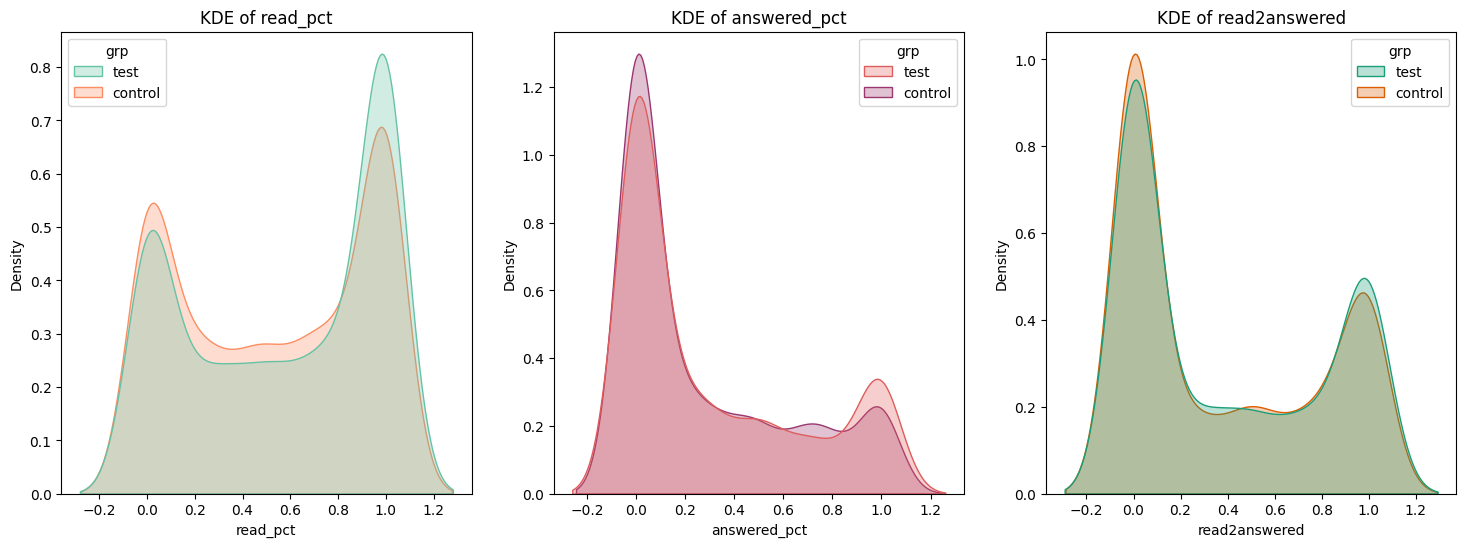

In [16]:
# set the figure size
plt.figure(figsize=(18, 6))

# Plot read_pct KDE
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x ='read_pct', hue='grp', palette='Set2', fill=True, alpha=0.3)
plt.title('KDE of read_pct')

# Plot answered_pct KDE
plt.subplot(1, 3, 2)
sns.kdeplot(data=df, x ='answered_pct', hue='grp', palette='flare', fill=True, alpha=0.3)
plt.title('KDE of answered_pct')

# Plot read2answered KDE
plt.subplot(1, 3, 3)
sns.kdeplot(data=df, x ='read2answered', hue='grp', palette='Dark2', fill=True, alpha=0.3)
plt.title('KDE of read2answered')

In [18]:
# Bootstrapped means of read_pct
# Creating a list with bootstrapped means for each AB-group
boot_read_pct = []
for i in range(1000):
    boot_mean = df.sample(frac=1, replace=True).groupby('grp')['read_pct'].mean()
    boot_read_pct.append(boot_mean)

boot_read_pct = pd.DataFrame(boot_read_pct)

In [19]:
boot_read_pct.head()

grp,control,test
read_pct,0.547314,0.572913
read_pct,0.536122,0.593135
read_pct,0.536704,0.590364
read_pct,0.536088,0.595084
read_pct,0.524598,0.580864


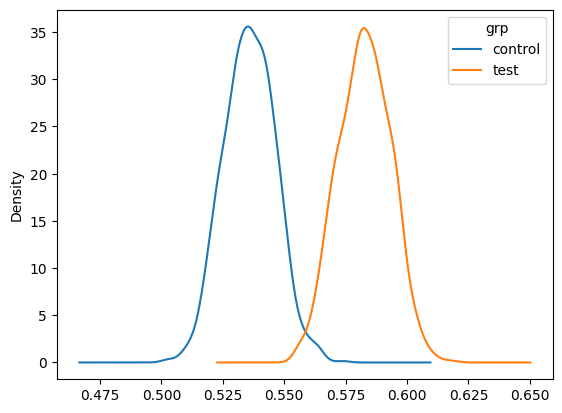

In [20]:
# A Kernel Density Estimate plot of the bootstrap distributions
boot_read_pct.plot(kind='kde')
plt.show()

In [21]:
boot_read_pct.head()

grp,control,test
read_pct,0.547314,0.572913
read_pct,0.536122,0.593135
read_pct,0.536704,0.590364
read_pct,0.536088,0.595084
read_pct,0.524598,0.580864


In [22]:
# Adding a column with the % difference between the two AB-groups
boot_read_pct['diff'] = (boot_read_pct['test']/boot_read_pct['control']-1)*100
#тест/контроль - 1 - на скільки відостків тест більше контроля

In [23]:
boot_read_pct.head()

grp,control,test,diff
read_pct,0.547314,0.572913,4.677178
read_pct,0.536122,0.593135,10.634308
read_pct,0.536704,0.590364,9.998071
read_pct,0.536088,0.595084,11.004991
read_pct,0.524598,0.580864,10.725504


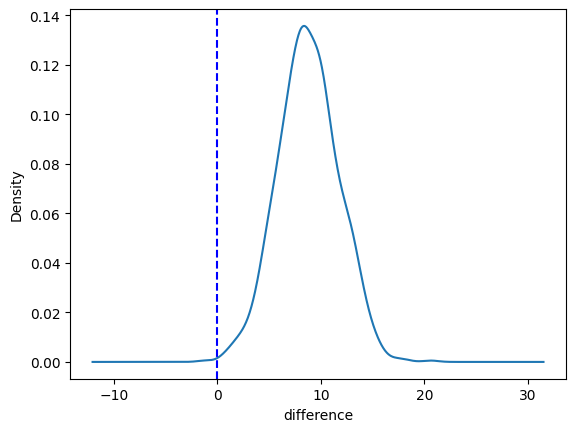

In [24]:
# Ploting the bootstrap % difference
ax = boot_read_pct['diff'].plot(kind = 'kde')
ax.set_xlabel('difference')
plt.axvline(0, color='blue', linestyle='--')
plt.show()

In [25]:
#What is the probability that the difference is above 0%?
prob = (boot_read_pct['diff']>0.0).mean()

# Pretty printing the probability
# print(f"{prob:.2f}")
print(f"{prob:.2%}")

99.90%


In [26]:
#Confidence Intervals
print (np.percentile(boot_read_pct['diff'], [2.5,97.5]))
# print(np.percentile(boot_read_pct['diff'], [0.5,99.5]))

[ 3.02623874 14.40871953]


# Bootstrap Function

In [27]:
def generate_bootstrap(data, group, metric, func, size=1000):
    boot = []
    for i in range(size):
        # Sample with replacement and group by the specified column
        sample = data.sample(frac=1, replace=True).groupby(group)[metric].agg(func)
        boot.append(sample)

    # Convert list of Series to DataFrame
    boot = pd.DataFrame(boot)
    return boot


def bootstrap_check(data, group, metric, func, size=1000):

    boot = generate_bootstrap(data, group, metric, func, size)

    # Calculate difference between 'test' and 'control'
    if 'test' in boot.columns and 'control' in boot.columns:
        boot['diff'] = (boot['test'] / boot['control'] - 1) * 100

        ci_diff = np.percentile(boot['diff'], [2.5, 97.5])
        ci_test = np.percentile(boot['test'], [2.5, 97.5])
        ci_control = np.percentile(boot['control'], [2.5, 97.5])

        print(f"Analyzing test results for {func} {metric}")
        print(f"95% Confidence interval for control: {ci_control}")
        print(f"95% Confidence interval for test: {ci_test}")
        print(f"95% Confidence interval for difference: {ci_diff}")

        boot['diff'].plot(kind='kde')
        plt.axvline(0, color='blue', linestyle='--')
        ax.set_xlabel('difference between test and control, in pct')
        plt.show()
    else:
        print("Columns 'test' and 'control' not found in the bootstrapped data.")

In [29]:
df.head(2)

,grp,applies,read_applies,answered_applies,read_pct,answered_pct,read2answered
0,test,42,7,0,0.166667,0.000000,0.0
1,test,7,6,6,0.857143,0.857143,1.0


Analyzing test results for mean read_pct
95% Confidence interval for control: [0.51555629 0.55727176]
95% Confidence interval for test: [0.56181423 0.6042566 ]
95% Confidence interval for difference: [ 3.03953074 14.87908409]


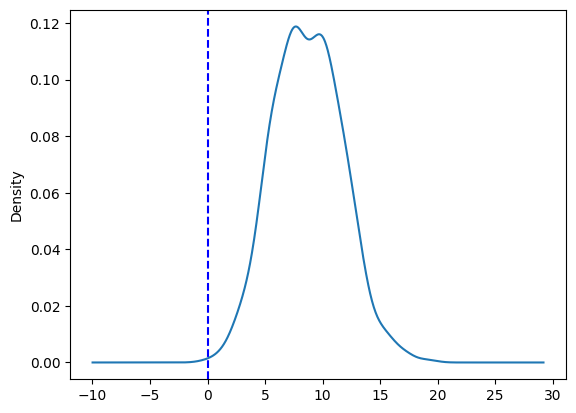

In [33]:
bootstrap_check(data=df, group='grp', metric='read_pct', func='mean')

Analyzing test results for median read_pct
95% Confidence interval for control: [0.5   0.625]
95% Confidence interval for test: [0.62326858 0.73401361]
95% Confidence interval for difference: [ 4.16666667 38.46153846]


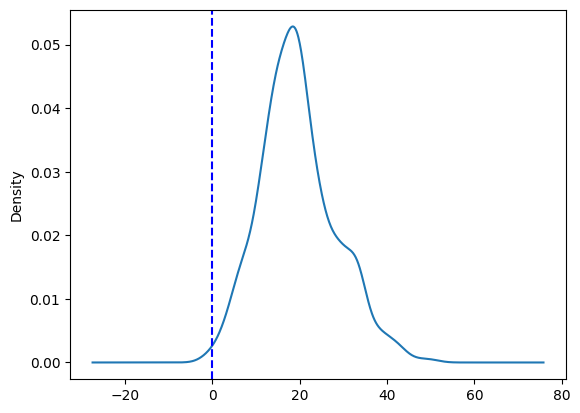

In [34]:
bootstrap_check(data=df, group='grp', metric='read_pct', func='median')

Analyzing test results for mean read2answered
95% Confidence interval for control: [0.34733015 0.38960439]
95% Confidence interval for test: [0.36421319 0.40895497]
95% Confidence interval for difference: [-3.60210437 14.00109826]


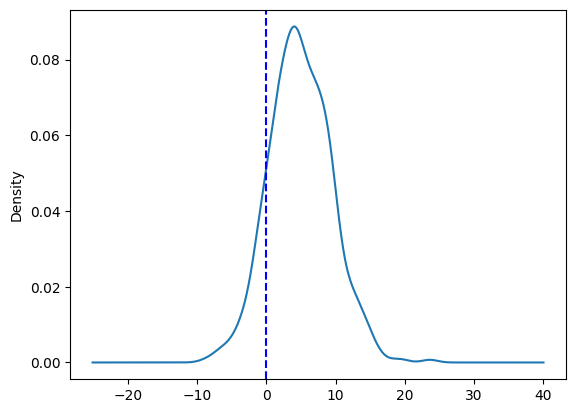

In [35]:
bootstrap_check(data=df, group='grp',metric = 'read2answered', func='mean')

# Option Three: Test

In [36]:
#check the stats for calculator
df.groupby('grp')['read_pct'].agg(['count', 'mean', 'std'])

,count,mean,std
grp,,,
control,1400,0.53644,0.391734
test,1395,0.58268,0.398076


In [38]:
# A/B Testing Function - Quick Solution
# didn't wrote this, found on kaggle
# https://www.kaggle.com/code/bokshalex/user-aggregated-data-a-b-test

def AB_Test(dataframe, group, target):

    # Split A/B
    groupA = dataframe[dataframe[group] == "control"][target]
    groupB = dataframe[dataframe[group] == "test"][target]

    # Assumption: Normality
    ntA = shapiro(groupA)[1] < 0.05
    ntB = shapiro(groupB)[1] < 0.05
    # H0: Distribution is Normal! - False
    # H1: Distribution is not Normal! - True

    if (ntA == False) & (ntB == False): # "H0: Normal Distribution"
        # Parametric Test
        # Assumption: Homogeneity of variances
        leveneTest = stats.levene(groupA, groupB)[1] < 0.05
        # H0: Homogeneity: False
        # H1: Heterogeneous: True

        if leveneTest == False:
            # Homogeneity
            ttest = stats.ttest_ind(groupA, groupB, equal_var=True)[1]
            # H0: M1 == M2 - False
            # H1: M1 != M2 - True
        else:
            # Heterogeneous
            ttest = stats.ttest_ind(groupA, groupB, equal_var=False)[1]
            # H0: M1 == M2 - False
            # H1: M1 != M2 - True
    else:
        # Non-Parametric Test
        ttest = stats.mannwhitneyu(groupA, groupB)[1]
        # H0: M1 == M2 - False
        # H1: M1 != M2 - True

    # Result
    temp = pd.DataFrame({
        "AB Hypothesis":[ttest < 0.05],
        "p-value":[ttest]
    })
    temp["Test Type"] = np.where((ntA == False) & (ntB == False), "Parametric", "Non-Parametric")
    temp["AB Hypothesis"] = np.where(temp["AB Hypothesis"] == False, "Fail to Reject H0", "Reject H0")
    temp["Comment"] = np.where(temp["AB Hypothesis"] == "Fail to Reject H0", "A/B groups are similar!", "A/B groups are not similar!")

    # Columns
    if (ntA == False) & (ntB == False):
        temp["Homogeneity"] = np.where(leveneTest == False, "Yes", "No")
        temp = temp[["Test Type", "Homogeneity","AB Hypothesis", "p-value", "Comment"]]
    else:
        temp = temp[["Test Type","AB Hypothesis", "p-value", "Comment"]]

    # Print Hypothesis
    #print("# A/B Testing Hypothesis")
    #print("H0: A == B")
    #print("H1: A != B", "\n")

    return temp

In [39]:
# Apply A/B Testing
AB_Test(dataframe=df, group = "grp", target = "read_pct")

AttributeError: `scipy.stats.stats` has no attribute `mannwhitneyu`; furthermore, `scipy.stats.stats` is deprecated and will be removed in SciPy 2.0.0.

In [43]:
import scipy.stats.stats as spt

In [45]:
print(dir(spt))

['alexandergovern', 'brunnermunzel', 'chisquare', 'combine_pvalues', 'cumfreq', 'describe', 'distributions', 'energy_distance', 'f_oneway', 'find_repeats', 'fisher_exact', 'friedmanchisquare', 'gmean', 'gstd', 'gzscore', 'hmean', 'iqr', 'jarque_bera', 'kendalltau', 'kruskal', 'ks_1samp', 'ks_2samp', 'kstest', 'kurtosis', 'kurtosistest', 'linregress', 'median_abs_deviation', 'mode', 'moment', 'mstats_basic', 'multiscale_graphcorr', 'normaltest', 'obrientransform', 'pearsonr', 'percentileofscore', 'pmean', 'pointbiserialr', 'power_divergence', 'rankdata', 'ranksums', 'relfreq', 'scoreatpercentile', 'sem', 'siegelslopes', 'sigmaclip', 'skew', 'skewtest', 'spearmanr', 'theilslopes', 'tiecorrect', 'tmax', 'tmean', 'tmin', 'trim1', 'trim_mean', 'trimboth', 'tsem', 'tstd', 'ttest_1samp', 'ttest_ind', 'ttest_ind_from_stats', 'ttest_rel', 'tvar', 'wasserstein_distance', 'weightedtau', 'zmap', 'zscore']
